# VP-SDE U-Net on CIFAR-10 Birds with Augmentation

Train and evaluate a continuous VP-SDE model with a custom U-Net on augmented CIFAR-10 bird images.


## Configuration


In [ ]:
RUN_TRAINING = True
RUN_EVALUATION_AFTER_TRAINING = True

LOAD_FROM_CHECKPOINT = False
CHECKPOINT_TO_LOAD = "/content/drive/MyDrive/DD2424/Project/bird_vp_sde_augmented_final_1760_epochs.pth"

SAVE_CHECKPOINTS = True

target_class_name = "bird"
batch_size=128

# Training
epochs=1760
learning_rate = 1e-4
weight_decay=1e-4
ema_decay=0.995

# VP-SDE beta schedule
bar_b_min = 0.1
bar_b_max = 20.0

# Sampling
sample_num_steps = 1000
sample_eps = 1e-3
sample_snr = 0.01
sample_corrector_steps = 0

# Evaluation
fid_num_generated = 1000
fid_gen_batch_size = 64
mem_num_generated = 64
mem_reference_images = 5000

# Paths
path = "/content/drive/MyDrive/DD2424/Project"


## Imports

Import Python, PyTorch, torchvision, plotting, and utility libraries. This also selects CUDA if it is available.


In [ ]:
import os
import sys
import math
import time
import copy
import subprocess
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Subset, DataLoader
from torchvision.utils import make_grid
from tqdm import tqdm


device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Google Drive

Mount Google Drive in Colab, create the project output directory, and add that directory to the Python path.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")
os.makedirs(path, exist_ok=True)
project_root = os.path.dirname(path) if os.path.basename(path) == "working_nets" else path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if path not in sys.path:
    sys.path.insert(0, path)

print("Project path:", path)
print("Files in project path:", os.listdir(path))


Mounted at /content/drive
Project path: /content/drive/MyDrive/DD2424/Project
Files in project path: ['bird_vp_sde_checkpoint_1760_epochs.pth', 'bird_vp_sde_augmented_500_epochs.pth', 'bird_vp_sde_augmented_1000_epochs.pth', 'bird_vp_sde_augmented_final__1600_epochs.pth', 'ema_generated_samples_grid.png', 'raw_vp_generated_samples_grid.png', 'comparison_ema_net_grid.png', 'comparison_raw_vp_net_grid.png', 'ema_net_augmented_1500_epochs_generated_grid.png', 'ema_net_augmented_1500_epochs_memorization_report.txt', 'ema_net_augmented_1500_epochs_memorization_generated_grid.png', 'ema_net_augmented_1500_epochs_evaluation_results.txt']


In [ ]:
from src.plotting import denormalize, imshow, show_batch_from_loader, show_images, plot_loss, save_tensor_images_as_grid
from src.sde import update_ema


## Load CIFAR-10 Bird Data

I defined two transforms: a plain transform for evaluation-related tasks and an augmented transform for training. The training transform applies both random horizontal flips and random padded crops, so it is not limited to flipping only. After this, I filter CIFAR-10 to keep only the target class and use the augmented dataloader for training.


In [ ]:
# Plain transform: used for visualization, FID real images, and memorization check
transform_plain = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Augmented transform: used for training
# Use reflection padding to avoid artificial black borders from RandomCrop.
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load full plain training set to find bird indices
trainset_plain_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_plain)

target_idx = trainset_plain_full.classes.index(target_class_name)

train_indices = [
    i for i, label in enumerate(trainset_plain_full.targets)
    if label == target_idx
]

# Plain bird training set
trainset_plain = Subset(trainset_plain_full, train_indices)

trainloader_plain = DataLoader(trainset_plain, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Augmented bird training set
trainset_aug_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)

trainset_aug = Subset(trainset_aug_full, train_indices)

trainloader_aug = DataLoader(trainset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# This is the training loader used by the model
trainloader = trainloader_aug

# Test set: plain transform, bird class only
testset_full = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_plain)

test_indices = [
    i for i, label in enumerate(testset_full.targets)
    if label == target_idx
]

testset = Subset(testset_full, test_indices)

testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Target class:", target_class_name)
print("Target class index:", target_idx)
print("Number of bird training images:", len(trainset_aug))
print("Number of bird test images:", len(testset))
print("Steps per epoch:", math.ceil(len(trainset_aug) / batch_size))


Target class: bird
Target class index: 2
Number of bird training images: 5000
Number of bird test images: 1000
Steps per epoch: 40


## Visualize Training Images


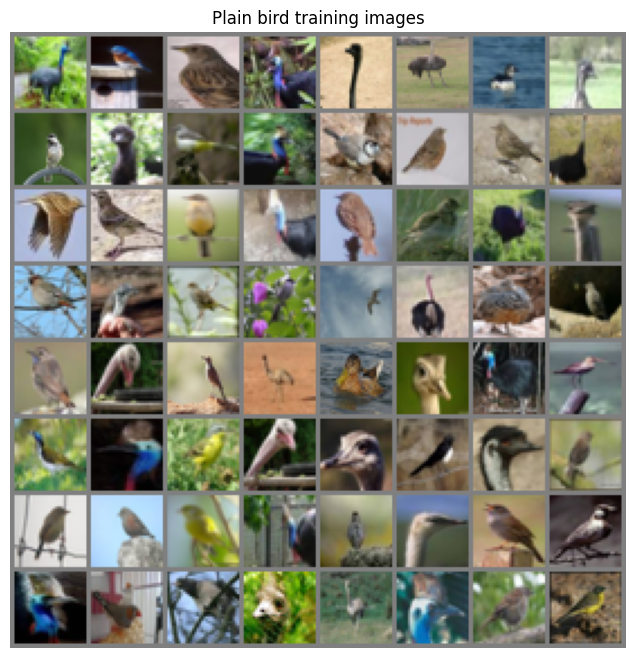

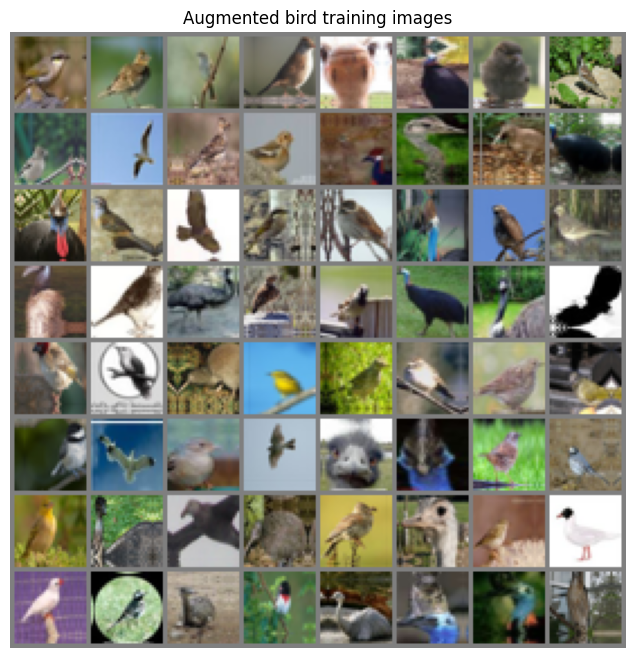

In [ ]:
show_batch_from_loader(trainloader_plain, title="Plain bird training images")
show_batch_from_loader(trainloader_aug, title="Augmented bird training images")


## U-Net Architecture


In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    Sinusoidal time embedding.
    Input t is continuous in [0, 1], but we multiply by 999 before using this.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim=dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(32, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)

        q = self.q(h).reshape(B, C, H * W).permute(0, 2, 1)
        k = self.k(h).reshape(B, C, H * W)
        v = self.v(h).reshape(B, C, H * W)

        attn = torch.softmax(q @ k / math.sqrt(C), dim=-1)
        out = (v @ attn.permute(0, 2, 1)).reshape(B, C, H, W)

        return x + self.proj(out)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.emb_proj = nn.Linear(emb_dim, out_ch * 2)
        self.act = nn.SiLU()

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(self.act(self.norm1(x)))

        scale, shift = self.emb_proj(emb).chunk(2, dim=1)
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]

        h = self.norm2(h)
        h = h * (1 + scale) + shift
        h = self.conv2(self.act(h))

        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, img_ch=3, base_ch=128):
        super().__init__()

        emb_dim = base_ch * 4

        self.time_emb = SinusoidalTimeEmbedding(emb_dim)

        self.emb_mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )

        self.conv_in = nn.Conv2d(img_ch, base_ch, 3, padding=1)

        # Encoder
        self.down1 = ResBlock(base_ch, 128, emb_dim)
        self.ds0 = Downsample(128)

        self.down2 = ResBlock(128, 256, emb_dim)
        self.ds1 = Downsample(256)

        self.down3 = ResBlock(256, 512, emb_dim)
        self.attn16 = SelfAttention(512)
        self.ds2 = Downsample(512)

        self.down4 = ResBlock(512, 512, emb_dim)
        self.attn8 = SelfAttention(512)

        # Bottleneck
        self.mid1 = ResBlock(512, 512, emb_dim)
        self.mid_attn = SelfAttention(512)
        self.mid2 = ResBlock(512, 512, emb_dim)

        # Decoder
        self.up4 = ResBlock(1024, 512, emb_dim)
        self.attn8_up = SelfAttention(512)
        self.us2 = Upsample(512)

        self.up3 = ResBlock(1024, 512, emb_dim)
        self.attn16_up = SelfAttention(512)
        self.us1 = Upsample(512)

        self.up2 = ResBlock(768, 256, emb_dim)
        self.us0 = Upsample(256)

        self.up1 = ResBlock(384, 128, emb_dim)

        self.conv_out = nn.Conv2d(128, img_ch, 3, padding=1)

    def forward(self, x, t):
        emb = self.emb_mlp(self.time_emb(t * 999.0))

        x = self.conv_in(x)

        d1 = self.down1(x, emb)
        d1_down = self.ds0(d1)

        d2 = self.down2(d1_down, emb)
        d2_down = self.ds1(d2)

        d3 = self.down3(d2_down, emb)
        d3 = self.attn16(d3)
        d3_down = self.ds2(d3)

        d4 = self.down4(d3_down, emb)
        d4 = self.attn8(d4)

        mid = self.mid1(d4, emb)
        mid = self.mid_attn(mid)
        mid = self.mid2(mid, emb)

        u4 = self.up4(torch.cat([mid, d4], dim=1), emb)
        u4 = self.attn8_up(u4)
        u4_up = self.us2(u4)

        u3 = self.up3(torch.cat([u4_up, d3], dim=1), emb)
        u3 = self.attn16_up(u3)
        u3_up = self.us1(u3)

        u2 = self.up2(torch.cat([u3_up, d2], dim=1), emb)
        u2_up = self.us0(u2)

        u1 = self.up1(torch.cat([u2_up, d1], dim=1), emb)

        return self.conv_out(u1)


## VP-SDE Objective


In [ ]:
def perturbation_kernel(t, x0):
    integral_beta = bar_b_min * t + 0.5 * (bar_b_max - bar_b_min) * t ** 2
    mean = torch.exp(-0.5 * integral_beta).view(-1, 1, 1, 1) * x0
    std = torch.sqrt(1.0 - torch.exp(-integral_beta)).view(-1, 1, 1, 1)
    return mean, std


def vp_loss(x0, net):
    """Continuous VP-SDE denoising score-matching loss."""
    B = x0.shape[0]
    eps=1e-5
    t = torch.rand(B, device=device) * (1.0 - eps) + eps
    z = torch.randn_like(x0)

    mean, std = perturbation_kernel(t, x0)
    x_t = mean + std * z

    score_target = -z / std
    score_pred = net(x_t, t)
    loss = (std ** 2 * ((score_pred - score_target) ** 2)).mean()
    return loss


def beta_t(t):
    return bar_b_min + t * (bar_b_max - bar_b_min)


## EMA Utility


## Initialize or Load Checkpoint


In [ ]:
if LOAD_FROM_CHECKPOINT:
    print("Loading checkpoint:", CHECKPOINT_TO_LOAD)

    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=device)

    vp_net = UNet().to(device)
    ema_net = UNet().to(device)

    vp_net.load_state_dict(checkpoint["vp_net"])
    ema_net.load_state_dict(checkpoint["ema_net"])

    learning_rate = checkpoint.get("learning_rate", learning_rate)
    weight_decay=checkpoint.get("weight_decay", weight_decay)
    ema_decay=checkpoint.get("ema_decay", ema_decay)
    loss_hist = checkpoint.get("loss_hist", [])
    start_epoch=checkpoint.get("epochs", 0)

    print(start_epoch)

    optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    optimizer.load_state_dict(checkpoint["optimizer"])

    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(device)

                vp_net.train()
                ema_net.eval()

            for p in ema_net.parameters():
                p.requires_grad_(False)

                print("Loaded checkpoint.")
                print("Start epoch:", start_epoch)
                print("Loaded loss history length:", len(loss_hist))

else:
    print("Initializing new model.")

    vp_net = UNet().to(device)

    ema_net = copy.deepcopy(vp_net).to(device)
    ema_net.eval()

    for p in ema_net.parameters():
        p.requires_grad_(False)

        optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

        loss_hist = []
        start_epoch=0

        print("New model initialized.")


Initializing new model.


NameError: name 'UNet' is not defined

## Training Loop


In [ ]:
def train_vp_sde(vp_net, ema_net, optimizer, trainloader, start_epoch=0, epochs=1700, ema_decay=0.995, checkpoint_every=1000, checkpoint_prefix="bird_vp_sde_augmented"):
    global loss_hist
    end_epoch = start_epoch + epochs

    for epoch in tqdm(range(start_epoch, end_epoch)):
        vp_net.train()
        ema_net.eval()
        epoch_losses = []

        for i, (images, _) in enumerate(trainloader):
            images = images.to(device)
            loss = vp_loss(images, vp_net)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vp_net.parameters(), max_norm=1.0)
            optimizer.step()
            update_ema(ema_net, vp_net, decay=ema_decay)

            loss_hist.append(loss.item())
            epoch_losses.append(loss.item())

        if epoch % 10 == 0:
            print(f"VP epoch {epoch} | Mean loss {np.mean(epoch_losses):.4f}")

        if SAVE_CHECKPOINTS and checkpoint_every is not None and (epoch + 1) % checkpoint_every == 0:
            checkpoint_path = os.path.join(path, f"{checkpoint_prefix}_{epoch + 1}_epochs.pth")
            checkpoint = {"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
            checkpoint["epochs"] = epoch + 1
            checkpoint["batch_size"] = batch_size
            checkpoint["learning_rate"] = learning_rate
            checkpoint["weight_decay"] = weight_decay
            checkpoint["ema_decay"] = ema_decay
            checkpoint["bar_b_min"] = bar_b_min
            checkpoint["bar_b_max"] = bar_b_max
            checkpoint["augmentation"] = True
            checkpoint["target_class_name"] = target_class_name
            torch.save(checkpoint, checkpoint_path)
            print("Saved checkpoint:", checkpoint_path)

    return end_epoch


if RUN_TRAINING:
    print("Training VP-SDE model...")
    final_epoch = train_vp_sde(vp_net, ema_net, optimizer, trainloader_aug, start_epoch=start_epoch, epochs=epochs, ema_decay=ema_decay, checkpoint_every=1000, checkpoint_prefix="bird_vp_sde_augmented")
    final_checkpoint_path = os.path.join(path, f"bird_vp_sde_augmented_final_{final_epoch}_epochs.pth")
    checkpoint = {"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
    checkpoint["epochs"] = final_epoch
    checkpoint["batch_size"] = batch_size
    checkpoint["learning_rate"] = learning_rate
    checkpoint["weight_decay"] = weight_decay
    checkpoint["ema_decay"] = ema_decay
    checkpoint["bar_b_min"] = bar_b_min
    checkpoint["bar_b_max"] = bar_b_max
    checkpoint["augmentation"] = True
    checkpoint["target_class_name"] = target_class_name
    torch.save(checkpoint, final_checkpoint_path)
    print("Saved final checkpoint:", final_checkpoint_path)

else:
    final_epoch = start_epoch


Training VP-SDE model...


  0%|          | 1/1760 [00:29<14:35:30, 29.86s/it]

VP epoch 0 | Mean loss 0.0956


  1%|          | 11/1760 [05:14<13:49:12, 28.45s/it]

VP epoch 10 | Mean loss 0.0426


...

VP epoch 1740 | Mean loss 0.0261


 99%|█████████▉| 1751/1760 [13:54:53<04:17, 28.60s/it]

VP epoch 1750 | Mean loss 0.0257


100%|██████████| 1760/1760 [13:59:11<00:00, 28.61s/it]


Saved final checkpoint: /content/drive/MyDrive/DD2424/Project/bird_vp_sde_augmented_final_1760_epochs.pth


## Save Checkpoint


In [ ]:
checkpoint_path = os.path.join(path, f'bird_vp_sde_augmented_final__{1600}_epochs.pth')

torch.save({
    "vp_net": vp_net.state_dict(),
    "ema_net": ema_net.state_dict(),
    "optimizer": optimizer.state_dict(),
    "loss_hist": loss_hist,
    "epochs":1600,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "weight_decay": weight_decay,
    "ema_decay": ema_decay,
    "bar_b_min": bar_b_min,
    "bar_b_max": bar_b_max,
    "augmentation": True,
    "target_class_name": target_class_name,
}, checkpoint_path)

print("Saved checkpoint:", checkpoint_path)


Saved checkpoint: /content/drive/MyDrive/DD2424/Project/bird_vp_sde_augmented_final__1600_epochs.pth


## Plot Training Loss


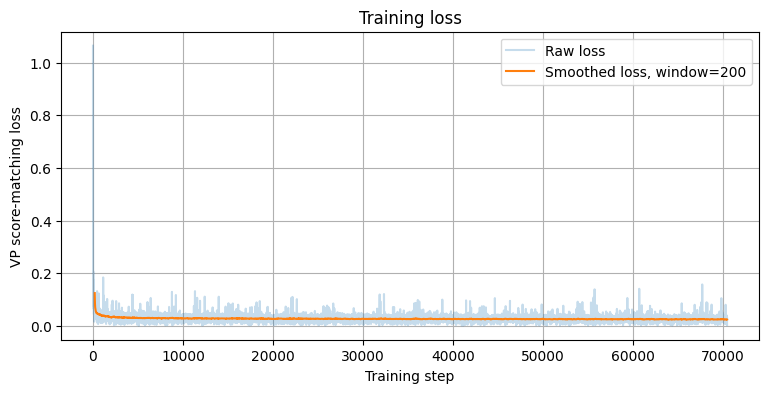

In [ ]:
plot_loss(loss_hist, smooth_window=200)


## Sampling


In [ ]:
@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=0.05, n_steps=1, eps=1e-12):
    B = x.shape[0]
    batch_t = torch.ones(B, device=device) * t

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)
        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()
        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=device) * t

    beta = beta_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = 0.5 * beta * x + beta * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_pc_vp_sde_continuous(net, num_samples=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.05, corrector_steps=0, denoise=True):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)
    x_mean = x

    for i in tqdm(range(num_steps - 1)):
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_vp(x, t, net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2
        x, x_mean = euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)


## Compare Raw and EMA Samples


100%|██████████| 999/999 [01:05<00:00, 15.18it/s]


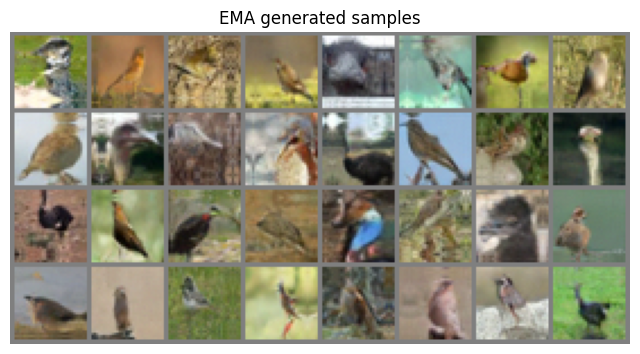

100%|██████████| 999/999 [01:05<00:00, 15.17it/s]


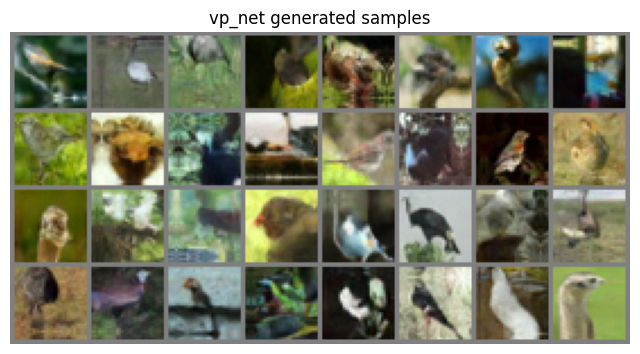

In [ ]:
samples_ema = sample_pc_vp_sde_continuous(ema_net, num_samples=32, img_shape=(3, 32, 32), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_ema, title="EMA generated samples", nrow=8)

samples_raw = sample_pc_vp_sde_continuous(vp_net, num_samples=32, img_shape=(3, 32, 32), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_raw, title="vp_net generated samples", nrow=8)


## Save Sample Grids


In [ ]:
save_tensor_images_as_grid(samples_ema, os.path.join(path, 'ema_generated_samples_grid.png'), nrow=8)

save_tensor_images_as_grid(samples_raw, os.path.join(path, 'vp_generated_samples_grid.png'), nrow=8)


Saved image grid: /content/drive/MyDrive/DD2424/Project/ema_generated_samples_grid.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/vp_generated_samples_grid.png


## Batched Sampling


In [ ]:
@torch.no_grad()
def generate_samples_in_batches(model, total_samples=1000, sample_batch_size=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True):
    model.eval()
    all_samples = []
    generated = 0

    while generated < total_samples:
        current_batch = min(sample_batch_size, total_samples - generated)
        samples = sample_pc_vp_sde_continuous(model, num_samples=current_batch, img_shape=img_shape, num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise)
        all_samples.append(samples.detach().cpu())
        generated += current_batch
        print(f"Generated {generated}/{total_samples} samples")

    return torch.cat(all_samples, dim=0)


## FID Evaluation


In [ ]:
def to_uint8_images(x):
    x = denormalize(x)
    x = (x * 255.0).round().clamp(0, 255).to(torch.uint8)
    return x


def install_fid_dependencies_if_needed():
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance
    except Exception:
        print("Installing torchmetrics and torch-fidelity...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics", "torch-fidelity"])
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance


@torch.no_grad()
def compute_fid_for_model(model, real_loader, num_generated=1000, gen_batch_size=64, real_max_images=1000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, feature=2048):
    FrechetInceptionDistance = install_fid_dependencies_if_needed()
    fid = FrechetInceptionDistance(feature=feature, normalize=False).to(device)
    model.eval()

    real_count = 0
    for real_images, _ in real_loader:
        real_images = real_images.to(device)
        fid.update(to_uint8_images(real_images), real=True)
        real_count += real_images.shape[0]
        if real_count >= real_max_images:
            break

    print("Real images added to FID:", real_count)

    gen_count = 0
    while gen_count < num_generated:
        current_batch = min(gen_batch_size, num_generated - gen_count)
        samples = sample_pc_vp_sde_continuous(
            model, num_samples=current_batch, img_shape=(3, 32, 32),
            num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise
        )
        fid.update(to_uint8_images(samples), real=False)
        gen_count += current_batch
        print(f"Generated images added to FID: {gen_count}/{num_generated}")

    fid_value = fid.compute().item()
    print("FID:", fid_value)
    return fid_value


def fid_sampling_steps_experiment(model, real_loader, steps_list=(100, 250, 500, 1000), num_generated=1000, gen_batch_size=64, corrector_steps=0):
    results = {}

    for steps in steps_list:
        print("\n====================================")
        print("Computing FID with num_steps =", steps)
        print("====================================")
        start_time = time.time()
        fid_value = compute_fid_for_model(model, real_loader, num_generated=num_generated, gen_batch_size=gen_batch_size,
            real_max_images=1000, num_steps=steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True)
        elapsed = time.time() - start_time
        results[steps] = {"fid": fid_value, "time_seconds": elapsed}
        print(f"num_steps={steps} | FID={fid_value:.4f} | time={elapsed:.2f}s")

    return results


## Memorization Check


In [ ]:
@torch.no_grad()
def collect_images_from_loader(loader, max_images=5000):
    all_images = []
    count = 0

    for images, _ in loader:
        images = images.to(device)
        all_images.append(images)
        count += images.shape[0]
        if count >= max_images:
            break

    all_images = torch.cat(all_images, dim=0)
    return all_images[:max_images]


@torch.no_grad()
def nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512):
    generated_images = generated_images.to(device)
    reference_images = reference_images.to(device)
    N = generated_images.shape[0]
    M = reference_images.shape[0]
    gen_flat = generated_images.reshape(N, -1)
    best_distances = torch.full((N,), float("inf"), device=device)
    best_indices = torch.zeros((N,), dtype=torch.long, device=device)

    for start in range(0, M, ref_batch_size):
        end = min(start + ref_batch_size, M)
        ref_batch = reference_images[start:end]
        ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)
        dists = torch.cdist(gen_flat, ref_flat, p=2) ** 2 / gen_flat.shape[1]
        min_dists, min_idx = dists.min(dim=1)
        better = min_dists < best_distances
        best_distances[better] = min_dists[better]
        best_indices[better] = start + min_idx[better]

    return best_indices.detach().cpu(), best_distances.detach().cpu()


def show_generated_vs_nearest(generated_images, reference_images, nearest_indices, nearest_distances=None, num_show=8):
    generated_images = generated_images.detach().cpu()
    reference_images = reference_images.detach().cpu()
    num_show = min(num_show, generated_images.shape[0])

    pairs = []
    for i in range(num_show):
        pairs.append(generated_images[i])
        pairs.append(reference_images[nearest_indices[i]])

    grid = make_grid(torch.stack(pairs, dim=0), nrow=2)
    img = denormalize(grid).numpy()
    plt.figure(figsize=(6, 3 * num_show))
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.axis("off")

    if nearest_distances is not None:
        mean_dist = nearest_distances[:num_show].mean().item()
        plt.title(f"Generated vs nearest training image | mean MSE={mean_dist:.6f}")
    else:
        plt.title("Generated vs nearest training image")

    plt.show()


@torch.no_grad()
def memorization_check(model, trainloader_reference, num_generated=64, generation_batch_size=64, max_reference_images=5000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, show_num=8):
    print("Collecting reference training images...")
    reference_images = collect_images_from_loader(trainloader_reference, max_images=max_reference_images)
    print("Reference images:", reference_images.shape)

    print("Generating images for memorization check...")
    generated_images = generate_samples_in_batches(model, total_samples=num_generated, sample_batch_size=generation_batch_size,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise).to(device)
    print("Generated images:", generated_images.shape)

    print("Finding nearest training neighbors...")
    nearest_indices, nearest_distances = nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512)
    print("Mean nearest-neighbor MSE:", nearest_distances.mean().item())
    print("Median nearest-neighbor MSE:", nearest_distances.median().item())
    print("Minimum nearest-neighbor MSE:", nearest_distances.min().item())
    print("Maximum nearest-neighbor MSE:", nearest_distances.max().item())

    show_generated_vs_nearest(generated_images.cpu(), reference_images.cpu(), nearest_indices, nearest_distances, num_show=show_num)
    return {
        "generated_images": generated_images.detach().cpu(), "reference_images": reference_images.detach().cpu(),
        "nearest_indices": nearest_indices, "nearest_distances": nearest_distances
    }


def plot_nearest_neighbor_distance_histogram(mem_results, bins=30):
    distances = mem_results["nearest_distances"].numpy()
    plt.figure(figsize=(7, 4))
    plt.hist(distances, bins=bins)
    plt.xlabel("Nearest-neighbor pixel MSE")
    plt.ylabel("Number of generated samples")
    plt.title("Memorization check: nearest-neighbor distance distribution")
    plt.grid(True)
    plt.show()


def save_memorization_report(mem_results, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    distances = mem_results["nearest_distances"].numpy()

    with open(filename, "w") as f:
        f.write("Memorization nearest-neighbor report\n")
        f.write("====================================\n")
        f.write(f"Number of generated samples: {len(distances)}\n")
        f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")
        f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")
        f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")
        f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")

    print("Saved memorization report:", filename)


'\ndef save_memorization_report(mem_results, filename):\n    os.makedirs(os.path.dirname(filename), exist_ok=True)\n\n    distances = mem_results["nearest_distances"].numpy()\n\n    with open(filename, "w") as f:\n        f.write("Memorization nearest-neighbor report\n")\n        f.write("====================================\n")\n        f.write(f"Number of generated samples: {len(distances)}\n")\n        f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")\n        f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")\n        f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")\n        f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")\n        f.write("\n")\n        f.write("Interpretation:\n")\n        f.write(\n            "Very small nearest-neighbor distances may indicate memorization, "\n            "especially if generated images visually match training images. "\n            "Larger distances suggest that generated image

## Compare Raw and EMA Models


In [ ]:
def compare_raw_vs_ema(vp_net, ema_net, num_samples=64, num_steps=1000, corrector_steps=0):
    torch.manual_seed(0)
    samples_raw = generate_samples_in_batches(
        model=vp_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    torch.manual_seed(0)
    samples_ema = generate_samples_in_batches(
        model=ema_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    show_images(samples_raw[:64], title="Raw vp_net samples", nrow=8)
    show_images(samples_ema[:64], title="EMA ema_net samples", nrow=8)
    save_tensor_images_as_grid(samples_raw[:64], os.path.join(path, 'comparison_raw_vp_net_grid.png'), nrow=8)
    save_tensor_images_as_grid(samples_ema[:64], os.path.join(path, 'comparison_ema_net_grid.png'), nrow=8)
    return samples_raw, samples_ema


In [ ]:
final_epoch=1600


## Full Evaluation


In [ ]:
def run_full_evaluation(model, model_name="ema_net", fid_num_generated=1000, mem_num_generated=64, num_steps=1000, corrector_steps=0):
    print("\n====================================")
    print("Running full evaluation for:", model_name)
    print("====================================")

    samples = generate_samples_in_batches(
        model=model, total_samples=64, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )
    show_images(samples[:64], title=f"{model_name}: generated samples", nrow=8)
    save_tensor_images_as_grid(samples[:64], os.path.join(path, f'{model_name}_generated_grid.png'), nrow=8)

    fid_value = compute_fid_for_model(
        model, testloader, num_generated=fid_num_generated, gen_batch_size=fid_gen_batch_size,
        real_max_images=1000, num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    mem_results = memorization_check(model, trainloader_plain, num_generated=mem_num_generated, generation_batch_size=64,
        max_reference_images=mem_reference_images, num_steps=num_steps, eps=1e-3, snr=0.01,
        corrector_steps=corrector_steps, denoise=True, show_num=8)
    plot_nearest_neighbor_distance_histogram(mem_results)

    results = {"model_name": model_name, "fid": fid_value, "num_steps": num_steps, "corrector_steps": corrector_steps}
    results["mem_mean_nn_mse"] = mem_results["nearest_distances"].mean().item()
    results["mem_median_nn_mse"] = mem_results["nearest_distances"].median().item()
    results["mem_min_nn_mse"] = mem_results["nearest_distances"].min().item()
    results["mem_max_nn_mse"] = mem_results["nearest_distances"].max().item()

    results_path = os.path.join(path, f"{model_name}_evaluation_results.txt")
    with open(results_path, "w") as f:
        for k, v in results.items():
            f.write(f"{k}: {v}\n")

    print("Saved evaluation results:", results_path)
    print(results)
    return results


## Evaluate After Training


100%|██████████| 999/999 [00:54<00:00, 18.23it/s]


Generated 24/24 samples


100%|██████████| 999/999 [00:54<00:00, 18.22it/s]


Generated 24/24 samples


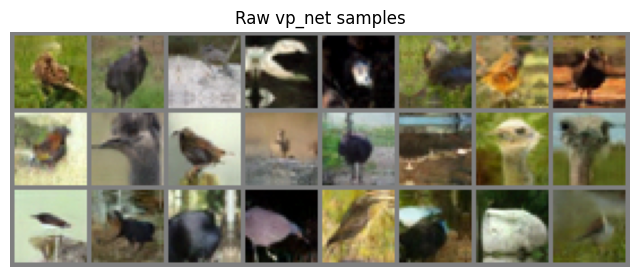

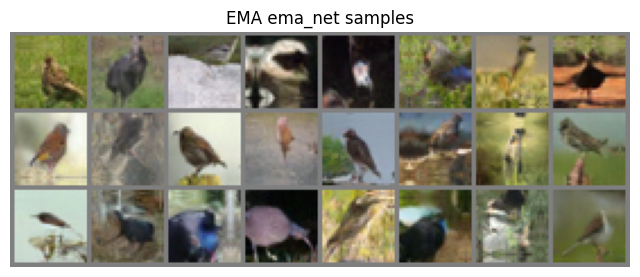

Saved image grid: /content/drive/MyDrive/DD2424/Project/comparison_raw_vp_net_grid.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/comparison_ema_net_grid.png

Running full evaluation for: vp_net1600_epochs


100%|██████████| 999/999 [02:05<00:00,  7.96it/s]


Generated 64/64 samples


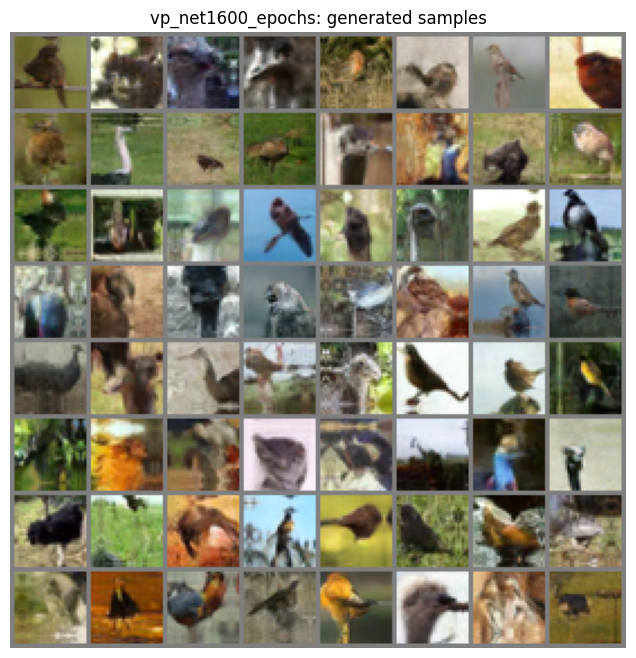

Saved image grid: /content/drive/MyDrive/DD2424/Project/vp_net1600_epochs_generated_grid.png
Real images added to FID: 1000


100%|██████████| 999/999 [02:05<00:00,  7.94it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [02:06<00:00,  7.92it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [01:24<00:00, 11.75it/s]


Generated images added to FID: 1000/1000
FID: 72.15308380126953
Reference images: torch.Size([5000, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [02:05<00:00,  7.97it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.10191857069730759
Median nearest-neighbor MSE: 0.09000454843044281
Minimum nearest-neighbor MSE: 0.0230078287422657
Maximum nearest-neighbor MSE: 0.3033079504966736


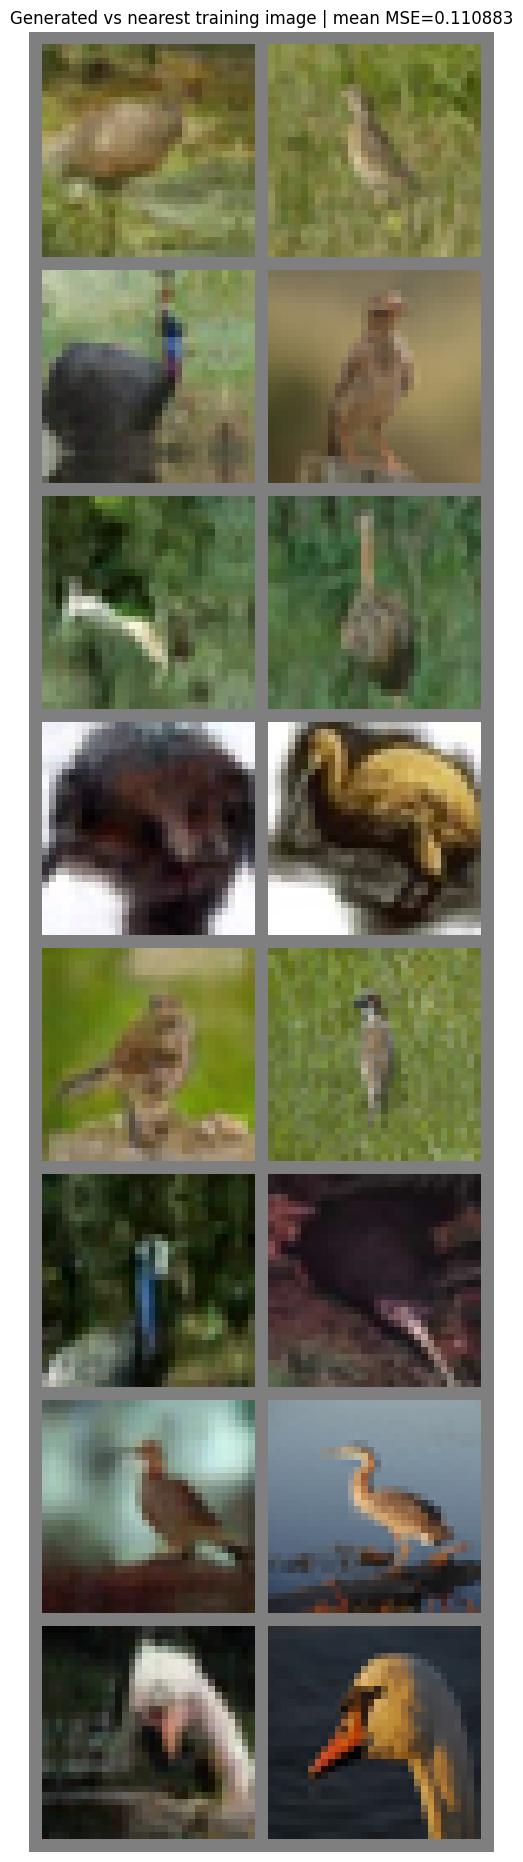

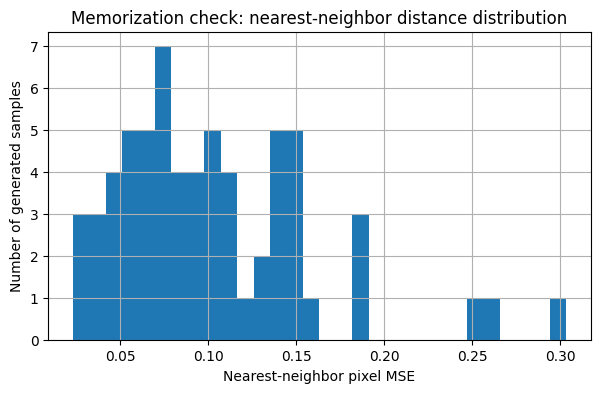

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/vp_net1600_epochs_evaluation_results.txt
{'model_name': 'vp_net1600_epochs', 'fid': 72.15308380126953, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.10191857069730759, 'mem_median_nn_mse': 0.09000454843044281, 'mem_min_nn_mse': 0.0230078287422657, 'mem_max_nn_mse': 0.3033079504966736}
Final VP_net evaluation results:
{'model_name': 'vp_net1600_epochs', 'fid': 72.15308380126953, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.10191857069730759, 'mem_median_nn_mse': 0.09000454843044281, 'mem_min_nn_mse': 0.0230078287422657, 'mem_max_nn_mse': 0.3033079504966736}


In [ ]:
if RUN_EVALUATION_AFTER_TRAINING:
    # Compare raw and EMA models visually
    samples_raw_compare, samples_ema_compare = compare_raw_vs_ema(vp_net=vp_net, ema_net=ema_net, num_samples=24, num_steps=sample_num_steps, corrector_steps=sample_corrector_steps)

    # Main full evaluation on VP model
    vp_net_results_ = run_full_evaluation(model=vp_net, model_name=f"vp_net{1600}_epochs",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final VP_net evaluation results:")
    print(vp_net_results_)


## Evaluate EMA Model



Running full evaluation for: EMA_net1600_epochs


100%|██████████| 999/999 [02:05<00:00,  7.94it/s]


Generated 64/64 samples


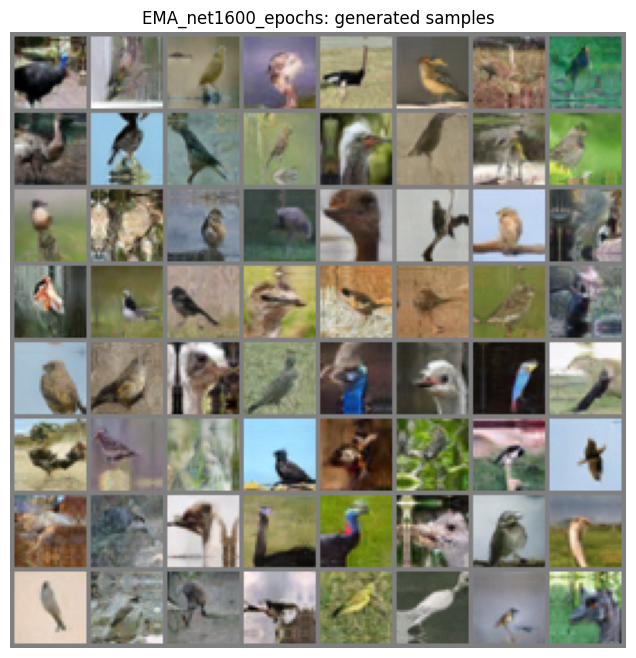

Saved image grid: /content/drive/MyDrive/DD2424/Project/EMA_net1600_epochs_generated_grid.png
Real images added to FID: 1000


100%|██████████| 999/999 [02:05<00:00,  7.94it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [02:06<00:00,  7.93it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [01:25<00:00, 11.67it/s]


Generated images added to FID: 1000/1000
FID: 61.10435485839844
Reference images: torch.Size([5000, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [02:05<00:00,  7.95it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.09075795859098434
Median nearest-neighbor MSE: 0.07800786197185516
Minimum nearest-neighbor MSE: 0.02636520378291607
Maximum nearest-neighbor MSE: 0.22954636812210083


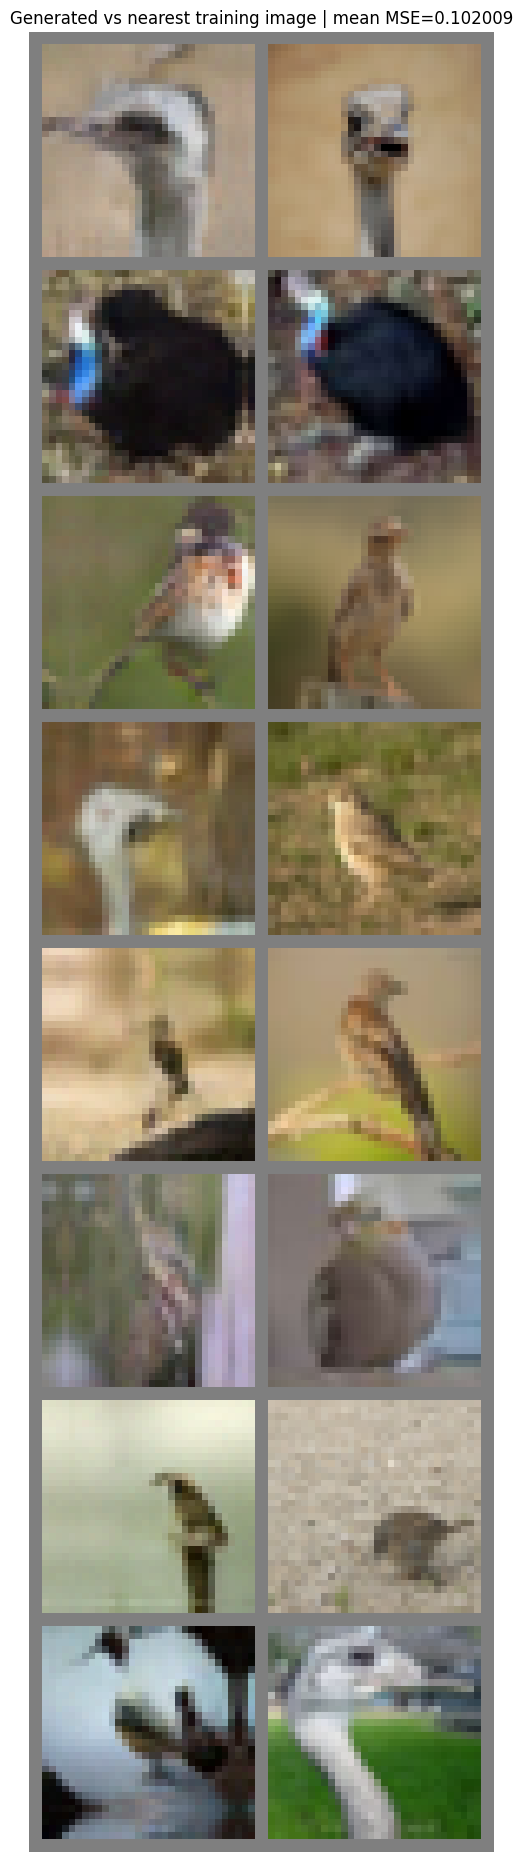

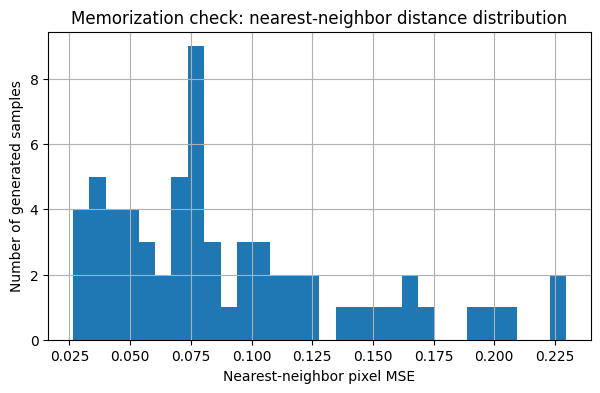

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/EMA_net1600_epochs_evaluation_results.txt
{'model_name': 'EMA_net1600_epochs', 'fid': 61.10435485839844, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.09075795859098434, 'mem_median_nn_mse': 0.07800786197185516, 'mem_min_nn_mse': 0.02636520378291607, 'mem_max_nn_mse': 0.22954636812210083}
Final EMA-net evaluation results:
{'model_name': 'EMA_net1600_epochs', 'fid': 61.10435485839844, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.09075795859098434, 'mem_median_nn_mse': 0.07800786197185516, 'mem_min_nn_mse': 0.02636520378291607, 'mem_max_nn_mse': 0.22954636812210083}


In [ ]:
if RUN_EVALUATION_AFTER_TRAINING:

    # Main full evaluation on EMA model
    vp_net_results_ = run_full_evaluation(model=ema_net, model_name=f"EMA_net{1600}_epochs",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final EMA-net evaluation results:")
    print(vp_net_results_)


## Sampling-Step FID Experiment


In [ ]:
# This is useful for your report, but it can take a long time.
# Uncomment if you want to run it.

# fid_step_results = fid_sampling_steps_experiment(
# model=ema_net,
# real_loader=testloader,
# steps_list=[100, 250, 500, 1000],
# num_generated=1000,
# gen_batch_size=64,
# corrector_steps=0
# )
#


## Compare with Non-Augmented Checkpoint


In [ ]:
eval_checkpoint_path = os.path.join(path, '/content/drive/MyDrive/DD2424/Project/bird_vp_sde_checkpoint_1760_epochs.pth')

eval_epoch = 1760

# the same settings as before
eval_num_steps = 1000
eval_corrector_steps = 0

# FID/memorization sample counts
# Keep these fixed across augmented and non-augmented models for fair comparison.
eval_fid_num_generated = 1000
eval_mem_num_generated = 64

assert os.path.exists(eval_checkpoint_path), f"Checkpoint not found: {eval_checkpoint_path}"

print("Evaluation checkpoint:", eval_checkpoint_path)
print("FID generated samples:", eval_fid_num_generated)
print("Memorization generated samples:", eval_mem_num_generated)
print("Sampling steps:", eval_num_steps)


Evaluation checkpoint: /content/drive/MyDrive/DD2424/Project/bird_vp_sde_checkpoint_1760_epochs.pth
FID generated samples: 1000
Memorization generated samples: 64
Sampling steps: 1000


## Load Saved Checkpoint


In [ ]:
checkpoint = torch.load(eval_checkpoint_path, map_location=device)

vp_net_1760 = UNet().to(device)
ema_net_1760 = UNet().to(device)

vp_net_1760.load_state_dict(checkpoint["vp_net"])
ema_net_1760.load_state_dict(checkpoint["ema_net"])

vp_net_1760.eval()
ema_net_1760.eval()

for p in vp_net_1760.parameters():
    p.requires_grad_(False)

for p in ema_net_1760.parameters():
    p.requires_grad_(False)

# Restore VP-SDE beta schedule from checkpoint if it exists
bar_b_min = checkpoint.get("bar_b_min", bar_b_min)
bar_b_max = checkpoint.get("bar_b_max", bar_b_max)

loaded_epoch = checkpoint.get("epochs", eval_epoch)
loaded_target_class = checkpoint.get("target_class_name", target_class_name)
loaded_augmentation = checkpoint.get("augmentation", "unknown")

print("Loaded checkpoint successfully.")
print("Loaded epoch:", loaded_epoch)
print("Target class:", loaded_target_class)
print("Augmentation:", loaded_augmentation)
print("bar_b_min:", bar_b_min)
print("bar_b_max:", bar_b_max)


Loaded checkpoint successfully.
Loaded epoch: 1760
Target class: bird
Augmentation: unknown
bar_b_min: 0.1
bar_b_max: 20.0


## Evaluate Raw Saved Model



Running full evaluation for: raw_vp_net_bird_1760_epochs


100%|██████████| 999/999 [01:58<00:00,  8.46it/s]


Generated 64/64 samples


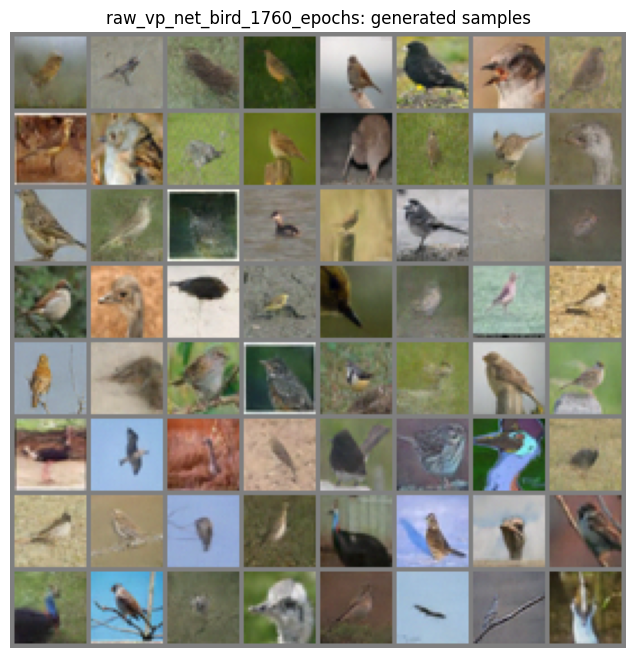

Saved image grid: /content/drive/MyDrive/DD2424/Project/raw_vp_net_bird_1760_epochs_generated_grid.png
Real images added to FID: 1000


100%|██████████| 999/999 [02:04<00:00,  8.05it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [02:05<00:00,  7.96it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [01:25<00:00, 11.67it/s]


Generated images added to FID: 1000/1000
FID: 61.143951416015625
Reference images: torch.Size([5000, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [02:05<00:00,  7.95it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.01772777922451496
Median nearest-neighbor MSE: 0.010801881551742554
Minimum nearest-neighbor MSE: 0.0012171268463134766
Maximum nearest-neighbor MSE: 0.09170961380004883


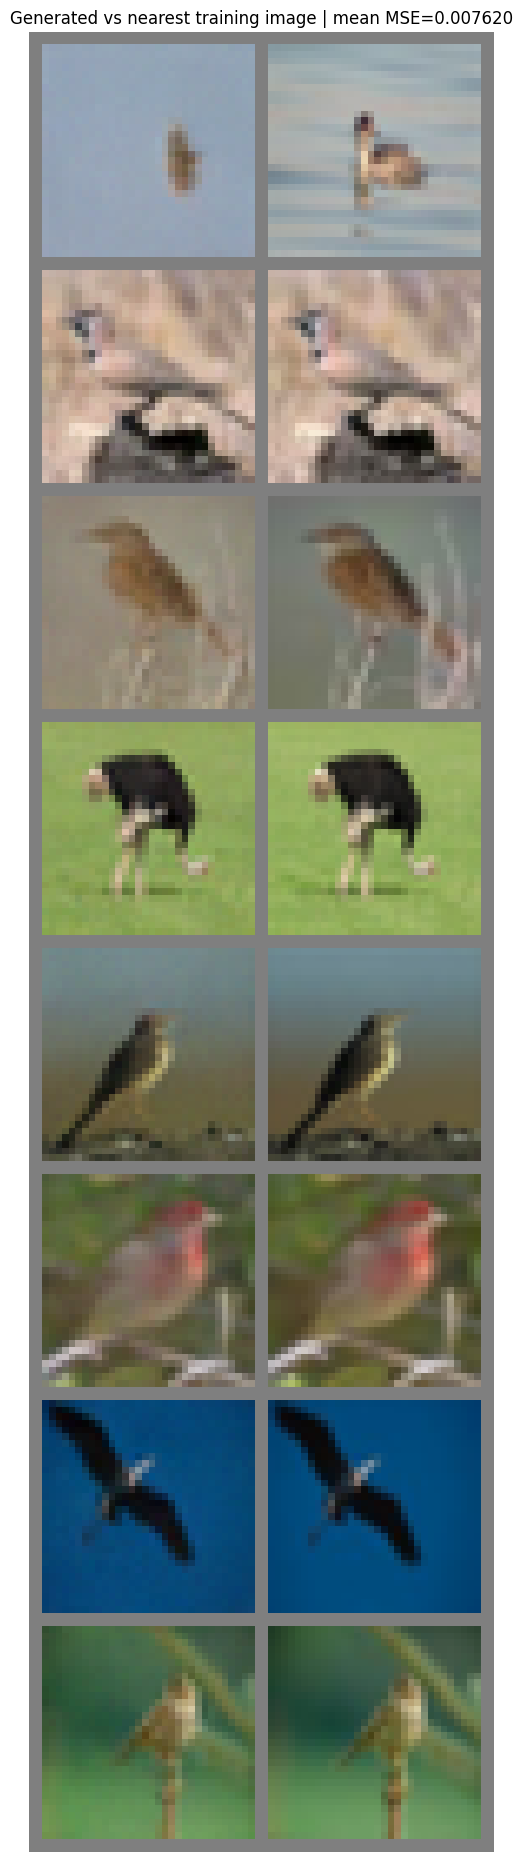

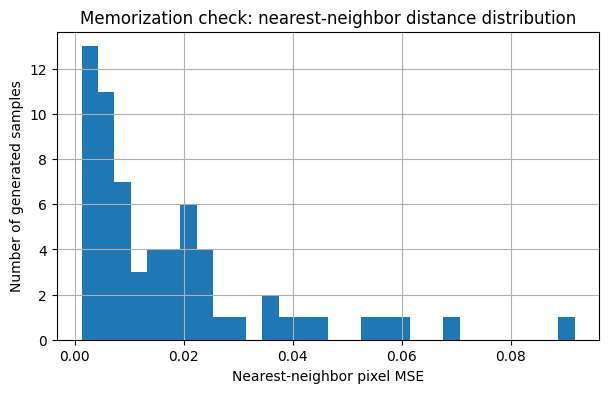

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/raw_vp_net_bird_1760_epochs_evaluation_results.txt
{'model_name': 'raw_vp_net_bird_1760_epochs', 'fid': 61.143951416015625, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.01772777922451496, 'mem_median_nn_mse': 0.010801881551742554, 'mem_min_nn_mse': 0.0012171268463134766, 'mem_max_nn_mse': 0.09170961380004883}
Raw VP-net evaluation results:
{'model_name': 'raw_vp_net_bird_1760_epochs', 'fid': 61.143951416015625, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.01772777922451496, 'mem_median_nn_mse': 0.010801881551742554, 'mem_min_nn_mse': 0.0012171268463134766, 'mem_max_nn_mse': 0.09170961380004883}


In [ ]:
raw_vp_1760_results = run_full_evaluation(model=vp_net_1760, model_name=f"raw_vp_net_bird_{eval_epoch}_epochs",
    fid_num_generated=eval_fid_num_generated, mem_num_generated=eval_mem_num_generated, num_steps=eval_num_steps,
    corrector_steps=eval_corrector_steps)

print("Raw VP-net evaluation results:")
print(raw_vp_1760_results)


## Evaluate EMA Saved Model



Running full evaluation for: ema_vp_net_bird_1760_epochs


100%|██████████| 999/999 [02:04<00:00,  8.00it/s]


Generated 64/64 samples


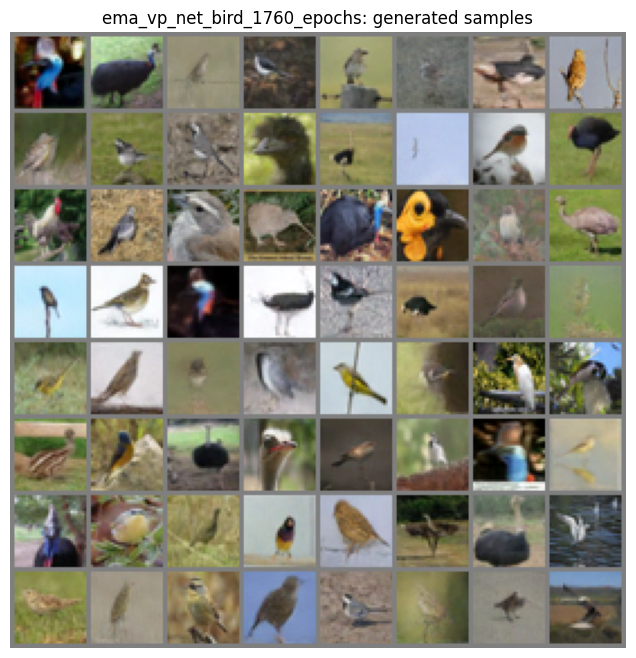

Saved image grid: /content/drive/MyDrive/DD2424/Project/ema_vp_net_bird_1760_epochs_generated_grid.png
Real images added to FID: 1000


100%|██████████| 999/999 [02:05<00:00,  7.93it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [02:05<00:00,  7.98it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [01:25<00:00, 11.66it/s]


Generated images added to FID: 1000/1000
FID: 52.12325668334961
Reference images: torch.Size([5000, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [02:05<00:00,  7.96it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.015074455179274082
Median nearest-neighbor MSE: 0.012434877455234528
Minimum nearest-neighbor MSE: 0.001230001449584961
Maximum nearest-neighbor MSE: 0.05825142189860344


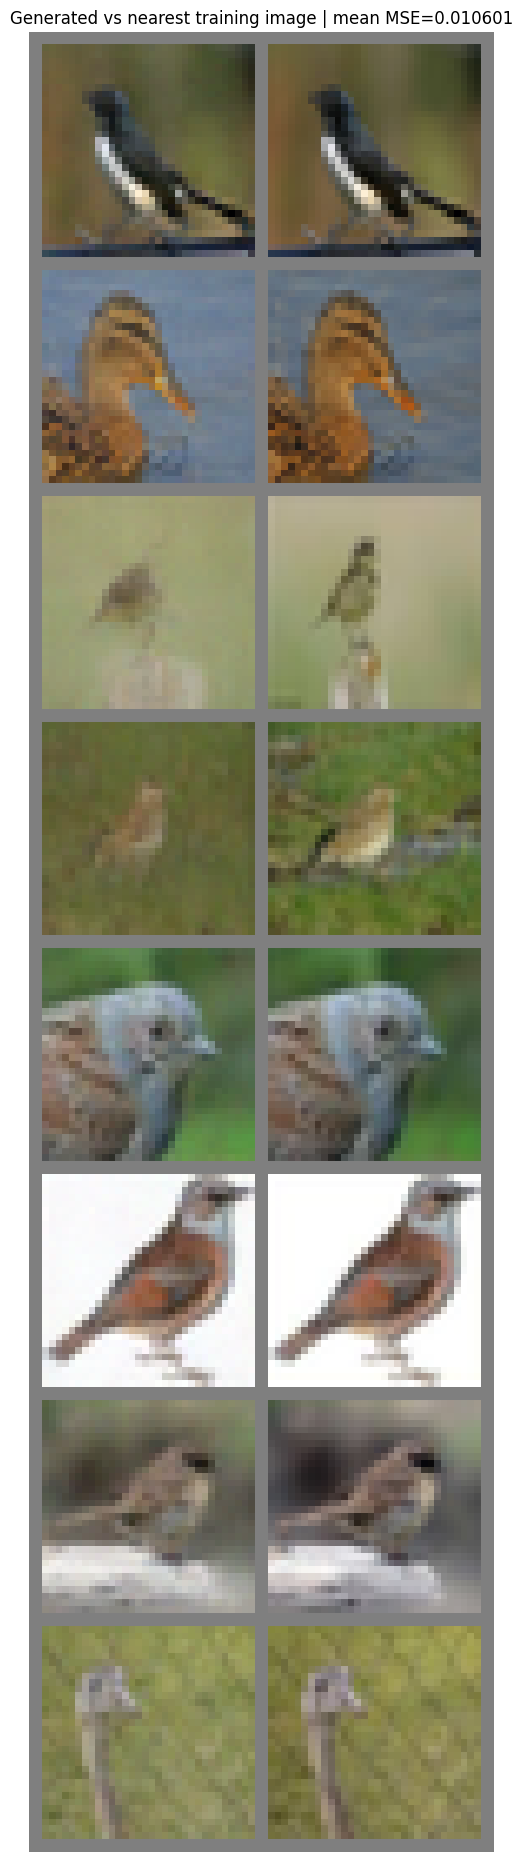

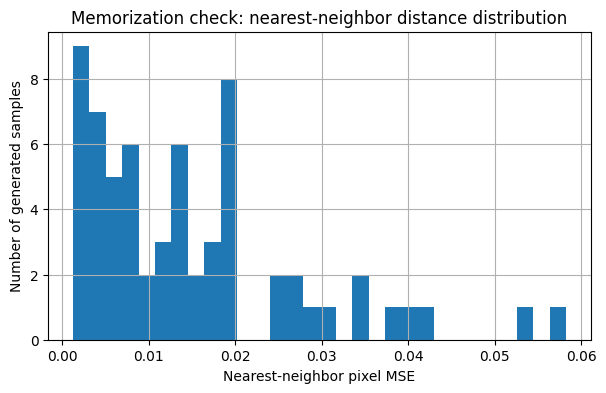

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/ema_vp_net_bird_1760_epochs_evaluation_results.txt
{'model_name': 'ema_vp_net_bird_1760_epochs', 'fid': 52.12325668334961, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.015074455179274082, 'mem_median_nn_mse': 0.012434877455234528, 'mem_min_nn_mse': 0.001230001449584961, 'mem_max_nn_mse': 0.05825142189860344}
EMA VP-net evaluation results:
{'model_name': 'ema_vp_net_bird_1760_epochs', 'fid': 52.12325668334961, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.015074455179274082, 'mem_median_nn_mse': 0.012434877455234528, 'mem_min_nn_mse': 0.001230001449584961, 'mem_max_nn_mse': 0.05825142189860344}


In [ ]:
ema_vp_1760_results = run_full_evaluation(model=ema_net_1760, model_name=f"ema_vp_net_bird_{eval_epoch}_epochs",
    fid_num_generated=eval_fid_num_generated, mem_num_generated=eval_mem_num_generated, num_steps=eval_num_steps,
    corrector_steps=eval_corrector_steps)

print("EMA VP-net evaluation results:")
print(ema_vp_1760_results)
